# Load libraries

In [1]:
import numpy as np
import matplotlib.pyplot as PLT


Duplicate key in file '/Users/nelsondiaz/.matplotlib/matplotlibrc', line 2 ('backend: GTK3Cairo')


Quadratic problem via GD (gradient descent)
===========================================


Consider the quadratic cost functional

   \begin{eqnarray}
     F(\mathbf{x}) & = & 0.5\| \mbox{Op}(\mathbf{x}) - \mathbf{b} \|_2^2 \qquad (1) 
   \end{eqnarray}

where

* $\nabla$ F is $L$-Lipschitz continuous: $\| \nabla F(\mathbf{x}) - \nabla F(\mathbf{y}) \|_2 \leq L(F)\| \mathbf{x} - \mathbf{y} \|_2$, 
* $\mathbf{x} \in \mathbb{R}^N$,
* $\mbox{Op}(\mathbf{x}) : \mathbb{R}^N \mapsto \mathbb{R}^L$ represents a forward operator,
* $\mathbf{b} \in \mathbb{R}^L$ represents the observed data.

## Synthetic data for $ \mbox{Op}(\mathbf{u}) = A \mathbf{u}$

Generate data involving a square random matrix and a random vector

$ \small \qquad \begin{array}{rcl}
 B & = & \mbox{randn}(N,N) \\
 A & = & B^TB + \alpha\cdot\mbox{diag}(N) \\
 A[:,k] & /= & \| A[:,k] \|_2 \;\; \forall k \qquad \mbox{ (normalization step)}
 & \\
 \mathbf{u}^* & = & \mbox{randn}(N,1) \\
 & \\
 b & = & A\mathbf{u}^* + \sigma\cdot \mbox{randn}(N,1) 
\end{array}$

In [2]:

def genData(N=500, alpha=50., eta = 0.05):
  
    B = np.random.randn(N, N)
  
    A = np.matmul(B.transpose(), B) + np.diag( alpha*np.ones([B.shape[1],],'f') )
    A /= np.linalg.norm(A,axis=0)
  
    xOri = np.random.randn(N,1)
  
    b = A.dot(xOri) + eta*np.random.randn(N,1)
  
 
    return(A, b, xOri)


# Functions

Some useful functions are included here.

In [3]:
def fwOp_MV(A,x,flagT=False):
    
    if flagT:
        z = A.transpose().dot(x)
    else:
        z = A.dot(x)

    return z    
        
# -----
# NOTE: for the functions belows, it is assumed that, for a given matrix A, 
#       the following lambda function is defined
#       fwOp = lambda x,flagT : fwOp_MV(A, x, flagT)

def QFuncCost(fwOp, x, b):
    z = fwOp(x, False) - b
    cost = 0.5*z.ravel().dot( z.ravel() )
    
    return cost

def QFuncGrad(fwOp, x, b):
    z = fwOp(x, False) - b
    grad = fwOp(z, True)
    
    return grad
    

***

## Functions for GD and variants

In [4]:
def GD(b, nIter, fProb, alpha0=0.01, flagVerbose=10):
    
    # fProb is a class (or dictionary) that implemnts specific function (e.g. cost, grad, etc.) for 
    # a particular problem, e.g. quadratic
    
    # b : observed data
    # stats : at least, cost functional
    
    statsGD = np.zeros( (nIter+1,2) )
    
    x = fProb['fwOp'](b*0,True)   # "lazy" initialization
    
    # cost for initial sol.
    statsGD[0,1] = fProb['cost'](fProb['fwOp'],x,b)
    
    
    for k in range(nIter):
        
        alpha = alpha0                           # CTE. step-size policy
        g = fProb['grad'](fProb['fwOp'],x,b)
        x = x - alpha*g

        # colect statistics
        statsGD[k+1,0] = k+1 
        statsGD[k+1,1]   = fProb['cost'](fProb['fwOp'],x,b)
        
        if flagVerbose > 0:
          if np.remainder(k,flagVerbose) == 0:

             print('Iter', k, '  cost ', statsGD[k+1,1])
        
    return(x, statsGD)  


## Generate the actual data

In [5]:
N = 2000

A, b, xori = genData(N, alpha=0.1*N)

## Test

In [10]:
fwOp_lin = lambda xx, flagTranspose : fwOp_MV(A,xx,flagTranspose)

QLin_Cost = {'cost': QFuncCost, 'grad':QFuncGrad, 'fwOp':fwOp_lin}

x = []
statsGD = []

sol , stats = GD(b, 200, QLin_Cost, alpha0=1e-6)
x.append(sol)
statsGD.append(stats)

sol , stats = GD(b, 200, QLin_Cost, alpha0=1e-3)
x.append(sol)
statsGD.append(stats)


Iter 0   cost  953.9667142115388
Iter 10   cost  953.9040453674723
Iter 20   cost  953.8413821005206
Iter 30   cost  953.7787244101123
Iter 40   cost  953.7160722956769
Iter 50   cost  953.653425756643
Iter 60   cost  953.5907847924403
Iter 70   cost  953.5281494024982
Iter 80   cost  953.4655195862458
Iter 90   cost  953.4028953431125
Iter 100   cost  953.3402766725279
Iter 110   cost  953.2776635739217
Iter 120   cost  953.2150560467234
Iter 130   cost  953.1524540903624
Iter 140   cost  953.089857704269
Iter 150   cost  953.0272668878724
Iter 160   cost  952.964681640603
Iter 170   cost  952.9021019618906
Iter 180   cost  952.839527851165
Iter 190   cost  952.7769593078566
Iter 0   cost  947.7197205736957
Iter 10   cost  888.1477655484358
Iter 20   cost  833.590679887458
Iter 30   cost  783.5654009456061
Iter 40   cost  737.6391546003067
Iter 50   cost  695.4239508961632
Iter 60   cost  656.5717034862573
Iter 70   cost  620.7699003579021
Iter 80   cost  587.7377619244223
Iter 90   c

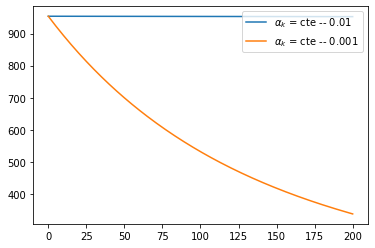

In [11]:
PLT.figure()
PLT.plot(statsGD[0][:,1], label=r'$\alpha_k$ = cte -- {0}'.format(1e-2) )
PLT.plot(statsGD[1][:,1], label=r'$\alpha_k$ = cte -- {0}'.format(1e-3) )
PLT.legend(loc='upper right')